# Notebook 02 - Analyse Exploratoire des Données (EDA)

**Projet** : Classification des Astéroïdes Potentiellement Dangereux (PHAs)  
**Module** : Machine Learning -- ENSA Tétouan -- Pr.Yacine EL YOUNOUSSI -- 2025-2026  
**Auteurs** : Bouchennou Ferdaouss · El Allouche Zakariyae · Tafraouti Sanae  


## Imports et configuration globale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.size": 11,
})
sns.set_palette("Set2")

print(" Bibliothèques chargées.")


 Bibliothèques chargées.


In [2]:
# Chargement du dataset

df = pd.read_csv("../data/dataset.csv")
print(f"Dataset complet chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head(5)


Dataset complet chargé : 20,000 lignes × 27 colonnes


,absolute_magnitude_h,estimated_diameter_min_km,is_sentry_object,is_potentially_hazardous,relative_velocity_km_per_second,miss_distance_astronomical,orbiting_body,n_approaches,min_miss_distance_au,max_velocity_km_s,...,orbit_uncertainty,minimum_orbit_intersection,data_arc_in_days,orbit_class_type,diameter_mean_km,diameter_uncertainty,perihelion_to_aphelion_ratio,threat_ratio,velocity_distance_ratio,observation_reliability
0,10.39,22.210328,0,0,3.983382,0.387314,EARTH,34,0.149462,6.084052,...,0.0,0.148353,46582.0,AMO,35.937066,27.453475,0.635542,0.004128,10.284639,0.0
1,15.59,2.025606,0,0,3.752797,1.822843,JUPTR,8,1.389955,5.004842,...,0.0,0.201318,41839.0,AMO,3.277499,2.503787,0.293163,0.061424,2.058761,0.0
2,13.82,4.576727,0,0,11.268954,0.166325,EARTH,3,0.082198,11.268954,...,0.0,0.079677,39281.0,AMO,7.405299,5.657145,0.272937,0.010759,67.752490,0.0
3,9.17,38.954262,0,0,15.749851,0.028684,MARS,5,0.028684,15.749851,...,0.0,0.343339,37087.0,AMO,63.029319,48.150115,0.304450,0.005447,549.090712,0.0
4,17.37,0.892391,0,0,10.502144,0.170464,EARTH,20,0.105277,11.080933,...,0.0,0.107969,33947.0,AMO,1.443918,1.103055,0.394085,0.074775,61.609112,0.0


---
# a) Exploration Univariée

**Objectif** : Pour chaque variable du dataset, produire :
- **Variables numériques** : histogramme, boxplot, statistiques descriptives (moyenne, médiane, σ, quartiles, min/max)
- **Variables catégorielles** : diagramme en barres des fréquences, identification des modalités rares (< 1 %)


### Identification et catégorisation des variables

In [3]:
# Catégorisation des colonnes
num_cols    = df.select_dtypes(include="number").columns.tolist()
cat_cols    = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
binary_cols = [c for c in num_cols if df[c].nunique() <= 2]
cont_cols   = [c for c in num_cols if c not in binary_cols]

print(f"Dimensions     : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire        : {df.memory_usage(deep=True).sum() / 1e6:.2f} Mo")
print()
print(f"Variables continues  ({len(cont_cols)}) : {cont_cols}")
print(f"Variables binaires   ({len(binary_cols)}) : {binary_cols}")
print(f"Variables catégor.   ({len(cat_cols)})  : {cat_cols}")


Dimensions     : 20,000 lignes × 27 colonnes
Mémoire        : 4.48 Mo

Variables continues  (23) : ['absolute_magnitude_h', 'estimated_diameter_min_km', 'relative_velocity_km_per_second', 'miss_distance_astronomical', 'n_approaches', 'min_miss_distance_au', 'max_velocity_km_s', 'semi_major_axis', 'eccentricity', 'inclination', 'perihelion_distance', 'aphelion_distance', 'orbital_period', 'perihelion_argument', 'orbit_uncertainty', 'minimum_orbit_intersection', 'data_arc_in_days', 'diameter_mean_km', 'diameter_uncertainty', 'perihelion_to_aphelion_ratio', 'threat_ratio', 'velocity_distance_ratio', 'observation_reliability']
Variables binaires   (2) : ['is_sentry_object', 'is_potentially_hazardous']
Variables catégor.   (2)  : ['orbiting_body', 'orbit_class_type']


### Statistiques descriptives - Variables continues

In [4]:
desc = df[cont_cols].describe(percentiles=[0.25, 0.50, 0.75]).T
desc.columns = ["N", "Moyenne", "Écart-type", "Min", "Q1 (25%)", "Médiane", "Q3 (75%)", "Max"]
desc["N"] = desc["N"].astype(int)
display(desc.round(4))


,N,Moyenne,Écart-type,Min,Q1 (25%),Médiane,Q3 (75%),Max
absolute_magnitude_h,20000,22.6893,2.9770,9.1700,20.3800,22.8000,25.0000,3.320000e+01
estimated_diameter_min_km,20000,0.1905,0.4560,0.0006,0.0266,0.0732,0.2231,3.895430e+01
relative_velocity_km_per_second,20000,14.1884,7.4419,0.2093,8.5757,13.2138,18.4420,9.364970e+01
miss_distance_astronomical,20000,0.2339,0.2181,0.0001,0.0869,0.1912,0.3520,1.999800e+00
n_approaches,20000,21.2597,32.1514,0.0000,2.0000,9.0000,25.0000,5.020000e+02
min_miss_distance_au,20000,0.0991,0.1476,0.0001,0.0249,0.0611,0.1299,1.998300e+00
max_velocity_km_s,20000,18.4490,8.5749,0.5685,12.3097,18.2444,23.4504,9.468990e+01
semi_major_axis,20000,1.7979,2.7795,0.5886,1.3155,1.7225,2.2011,3.502895e+02
eccentricity,20000,0.4454,0.1764,0.0040,0.3164,0.4589,0.5702,9.964000e-01
inclination,20000,12.6886,11.2188,0.0176,4.6398,8.9781,18.0359,1.543490e+02


---
### Groupe 1 - Features Physiques

| Variable | Description |
|----------|-------------|
| `absolute_magnitude_h` | Magnitude absolue - plus H faible = objet grand/brillant. PHAs ont H < 22. |
| `estimated_diameter_min_km` | Diamètre minimum estimé (km) |
| `diameter_mean_km` |  Diamètre moyen - **Critère NASA #1** (seuil : 0,14 km) |
| `diameter_uncertainty` |  Incertitude de mesure du diamètre (km) |


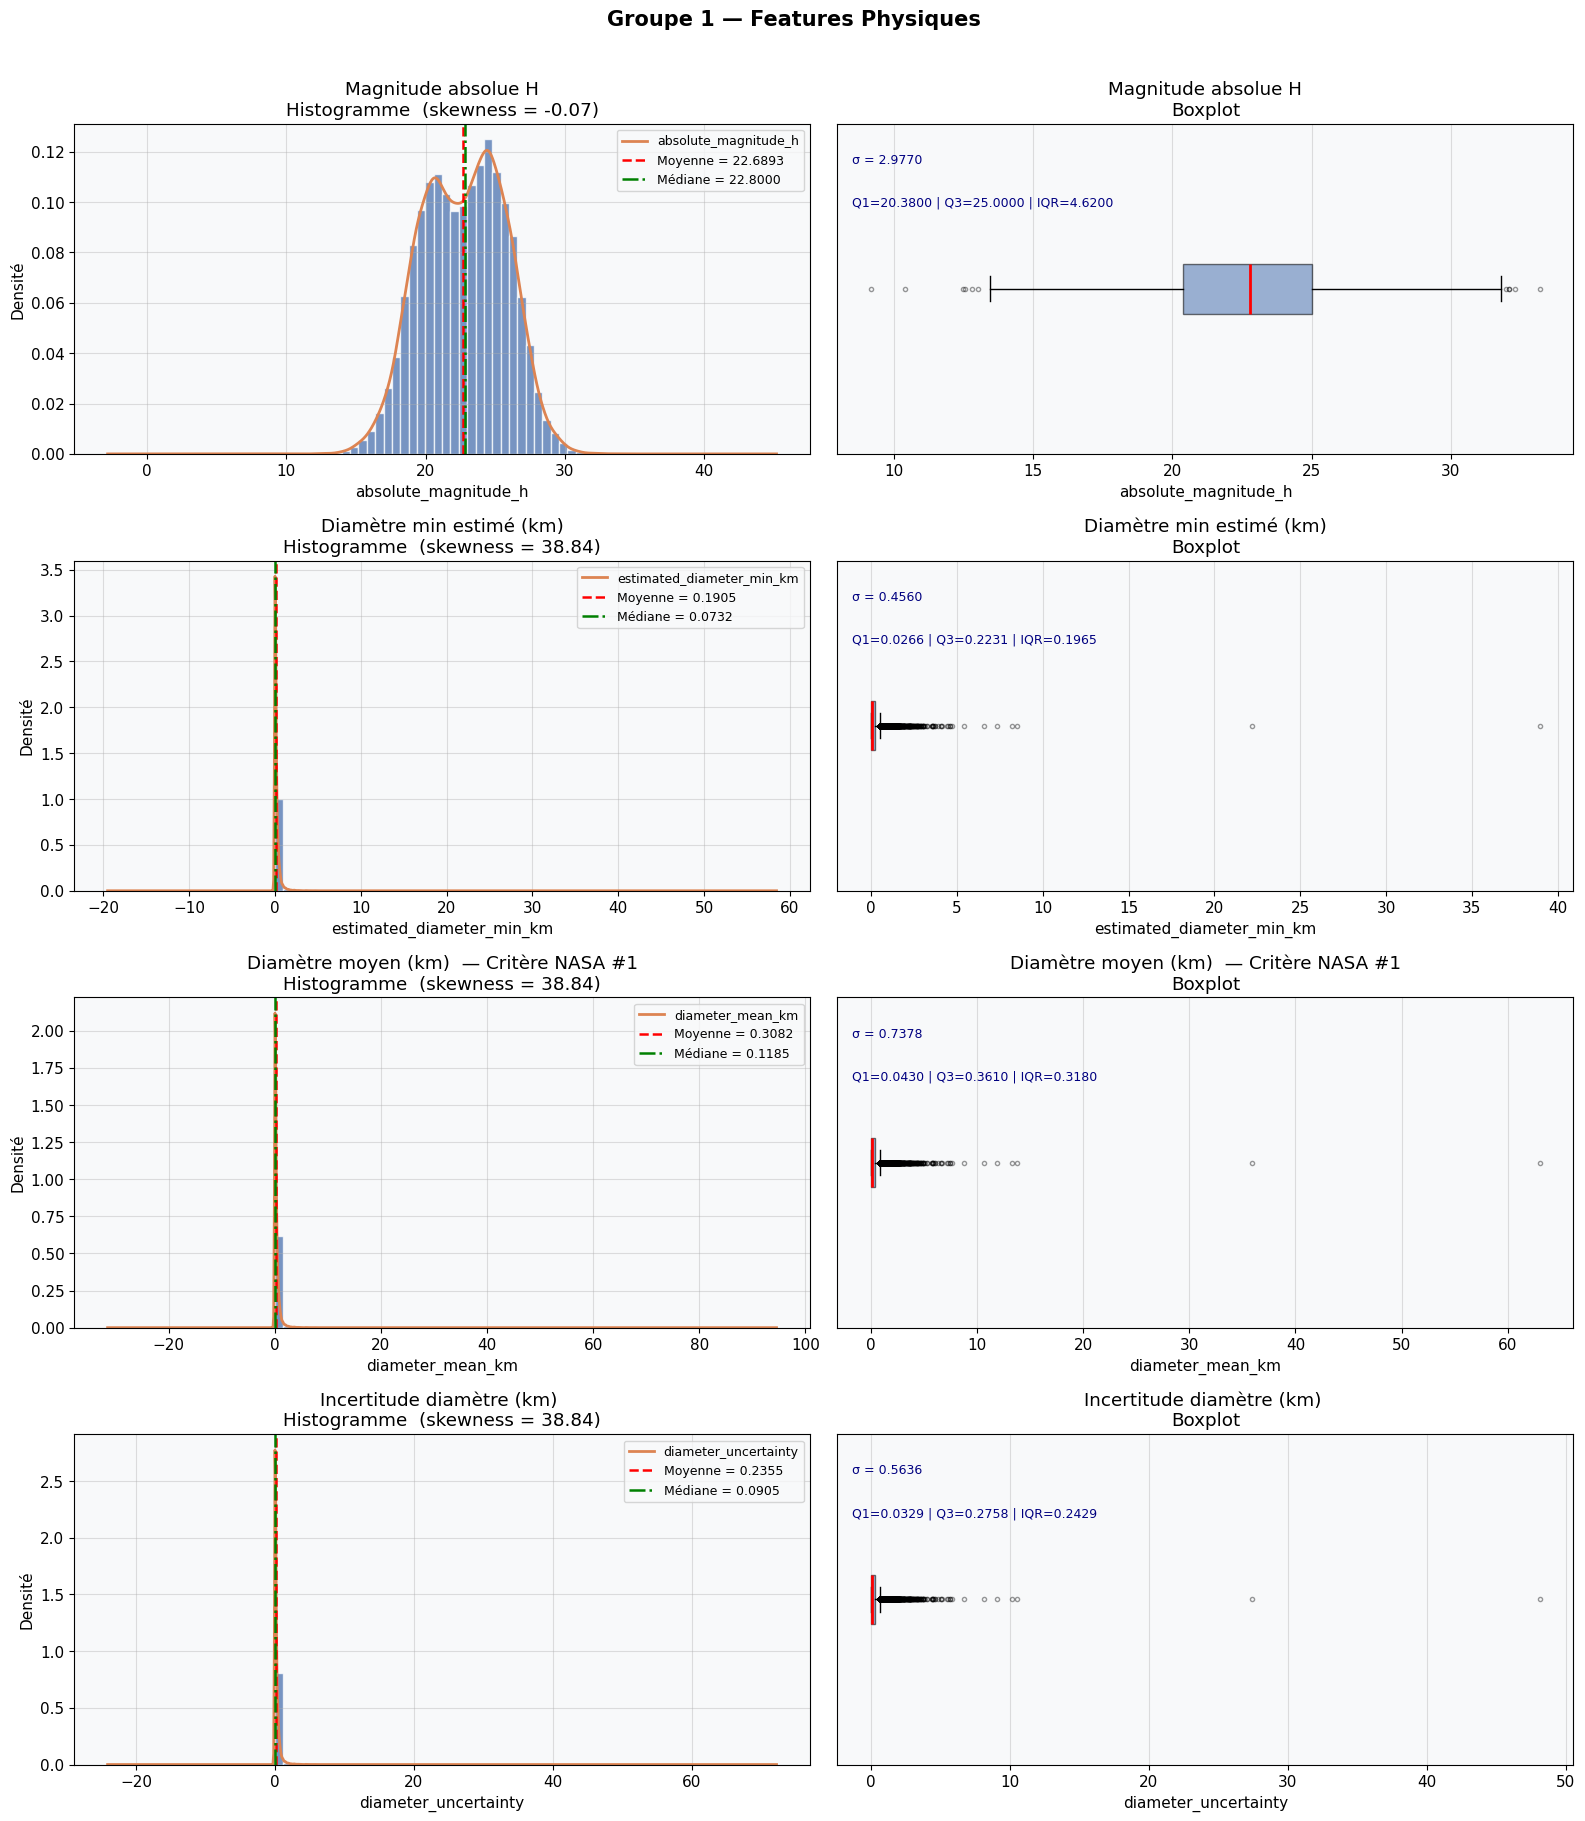

In [5]:
group1 = ["absolute_magnitude_h", "estimated_diameter_min_km",
          "diameter_mean_km", "diameter_uncertainty"]
group1_labels = {
    "absolute_magnitude_h":      "Magnitude absolue H",
    "estimated_diameter_min_km": "Diamètre min estimé (km)",
    "diameter_mean_km":          "Diamètre moyen (km)  — Critère NASA #1",
    "diameter_uncertainty":      "Incertitude diamètre (km) ",
}

fig, axes = plt.subplots(len(group1), 2, figsize=(16, 4.5 * len(group1)))
fig.suptitle("Groupe 1 — Features Physiques", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group1):
    s = df[col].dropna()
    label = group1_labels[col]

    # Histogramme + KDE
    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#4C72B0", alpha=0.75, edgecolor="white", density=True)
    s.plot.kde(ax=ax_h, color="#DD8452", lw=2)
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    # Boxplot
    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#4C72B0", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#DD8452"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="navy")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="navy")

plt.tight_layout()
plt.show()


---
### Groupe 2 - Features d'Approche

| Variable | Description |
|----------|-------------|
| `relative_velocity_km_per_second` | Vitesse relative lors de l'approche la plus récente (km/s) |
| `miss_distance_astronomical` | Distance de passage (UA) |
| `n_approaches` | Nombre total d'approches enregistrées |
| `min_miss_distance_au` | Distance minimale historique (UA) — proxy du MOID |
| `max_velocity_km_s` | Vitesse maximale historique (km/s) |


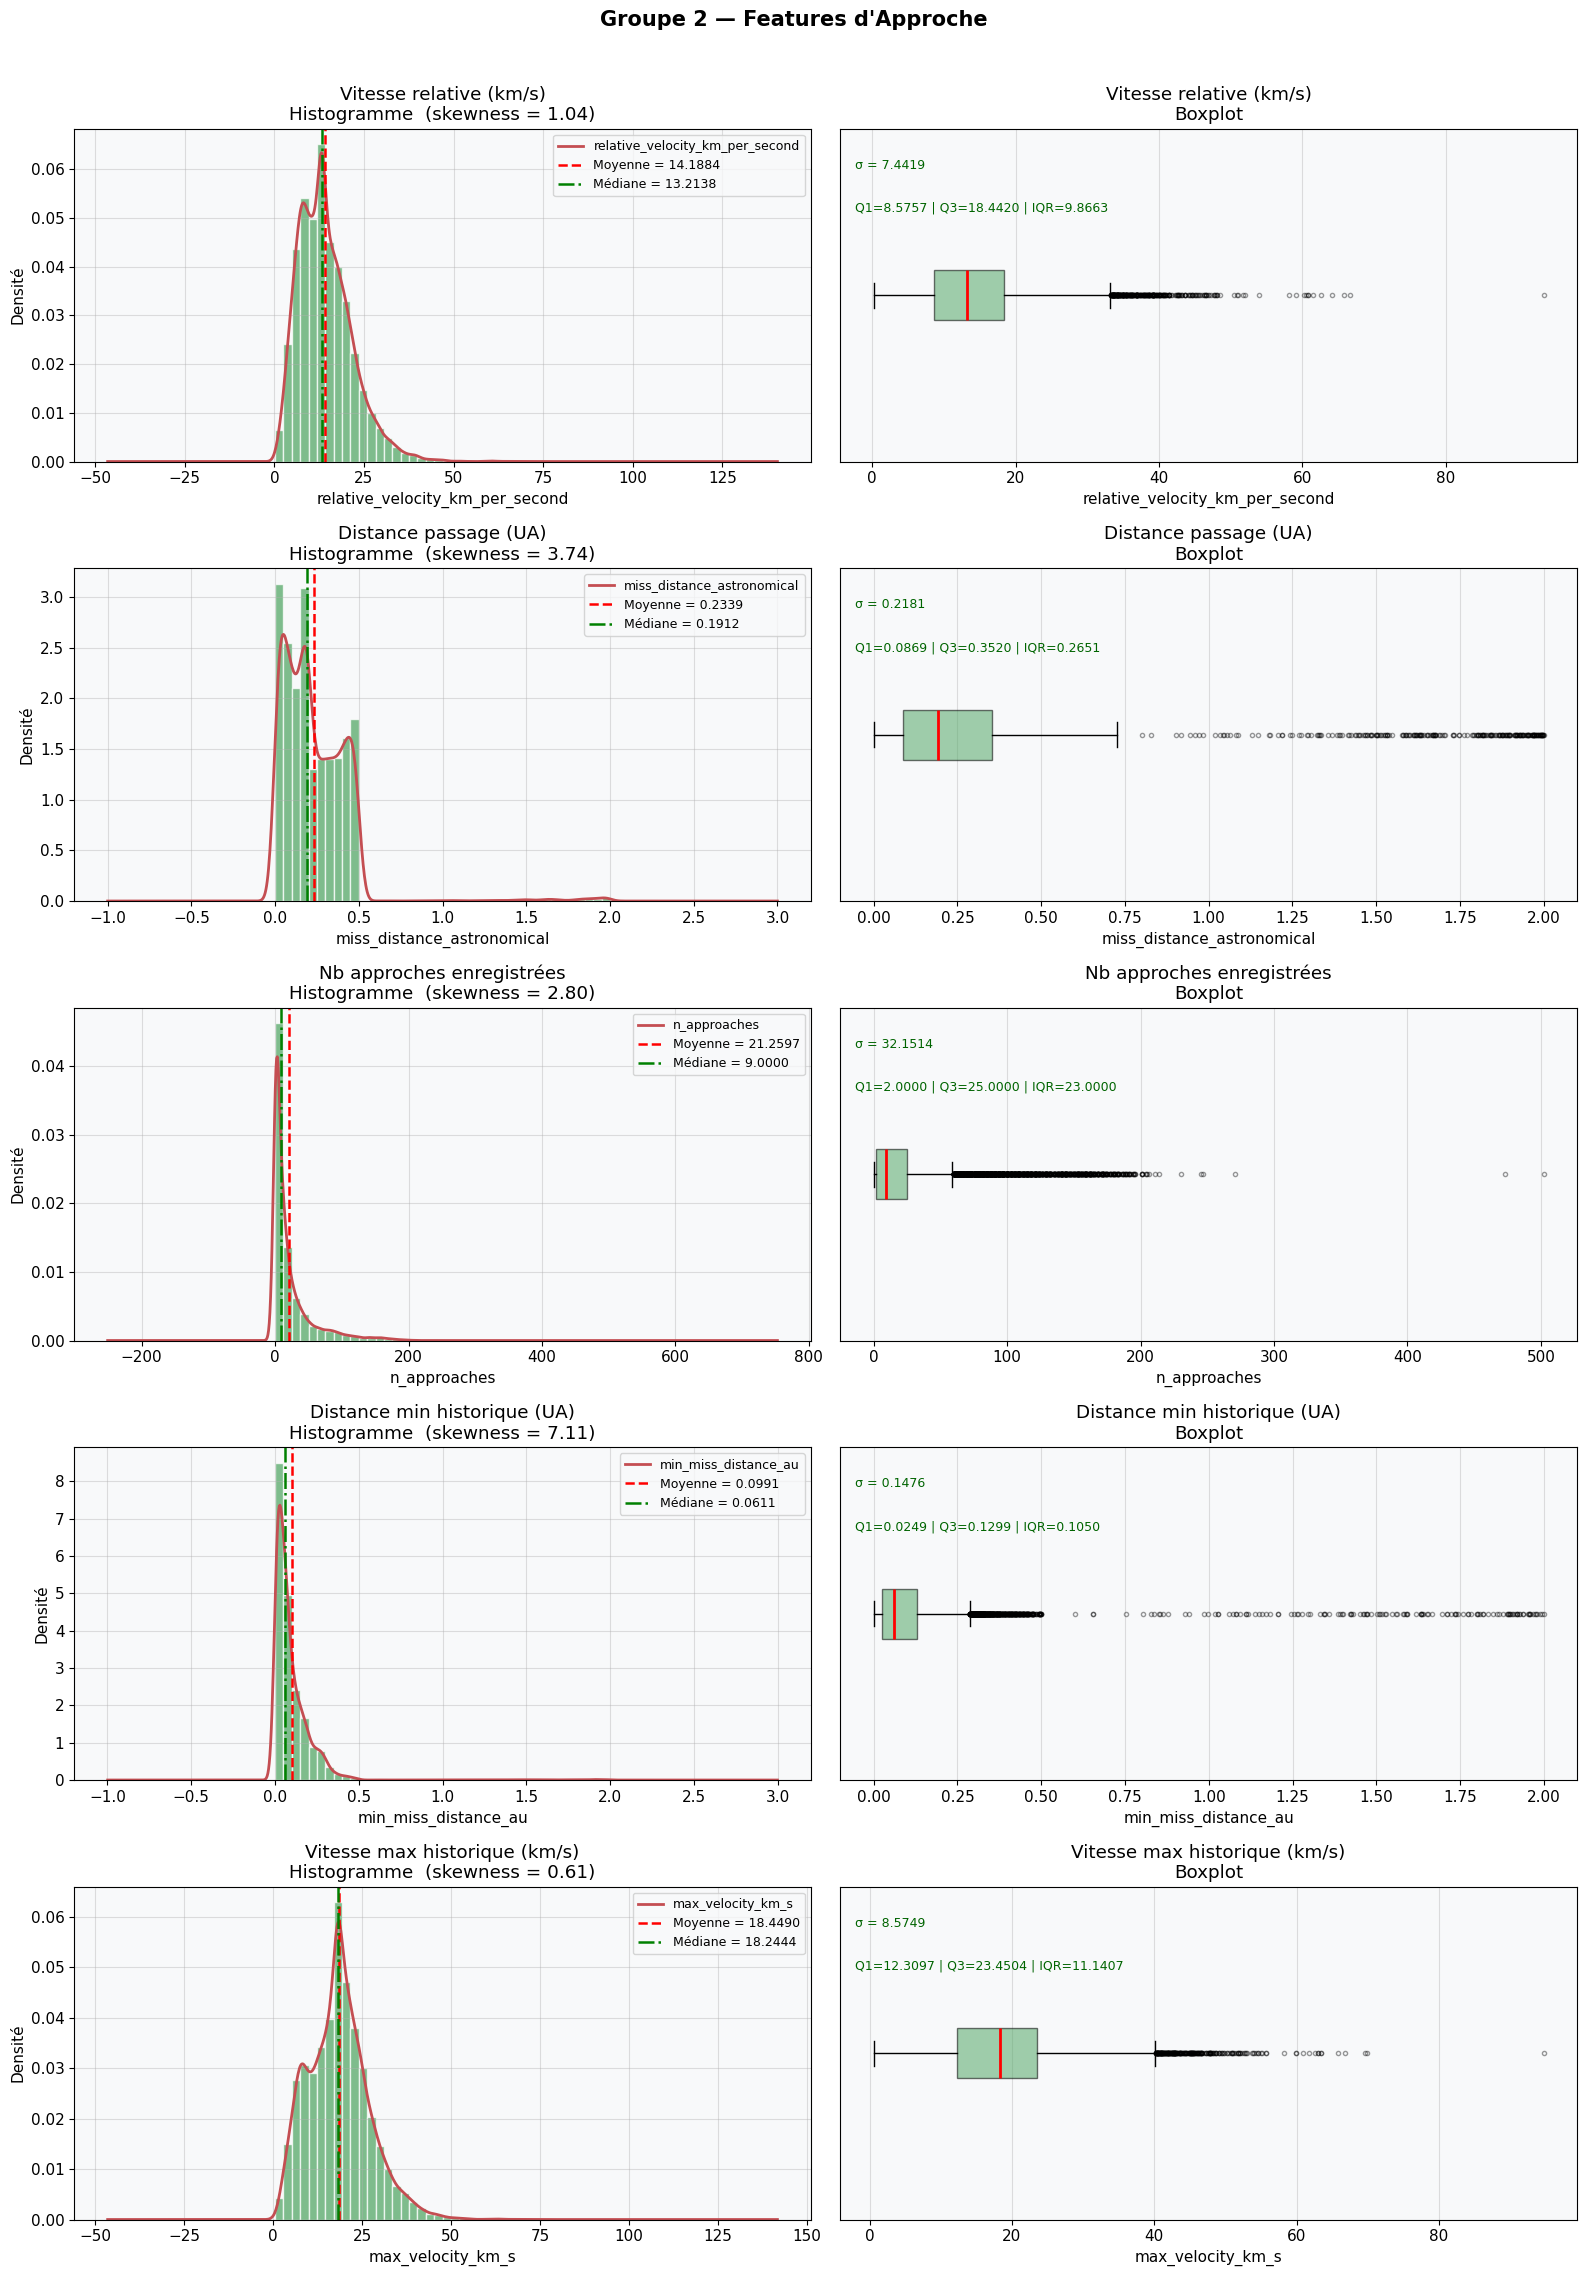

In [6]:
group2 = ["relative_velocity_km_per_second", "miss_distance_astronomical",
          "n_approaches", "min_miss_distance_au", "max_velocity_km_s"]
group2_labels = {
    "relative_velocity_km_per_second": "Vitesse relative (km/s)",
    "miss_distance_astronomical":      "Distance passage (UA)",
    "n_approaches":                    "Nb approches enregistrées",
    "min_miss_distance_au":            "Distance min historique (UA)",
    "max_velocity_km_s":               "Vitesse max historique (km/s)",
}

fig, axes = plt.subplots(len(group2), 2, figsize=(16, 4.5 * len(group2)))
fig.suptitle("Groupe 2 — Features d'Approche", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group2):
    s = df[col].dropna()
    label = group2_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#55A868", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#C44E52", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#55A868", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#C44E52"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="darkgreen")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="darkgreen")

plt.tight_layout()
plt.show()


---
### Groupe 3 - Features Orbitales

| Variable | Description |
|----------|-------------|
| `semi_major_axis` | Demi-grand axe (UA) |
| `eccentricity` | Excentricité [0–1] |
| `inclination` | Inclinaison (°) |
| `perihelion_distance` | Distance au périhélie (UA) |
| `aphelion_distance` | Distance à l'aphélie (UA) |
| `orbital_period` | Période orbitale (jours) |
| `perihelion_argument` | Argument du périhélie (°) |
| `orbit_uncertainty` | Code d'incertitude JPL (0–9) |
| `minimum_orbit_intersection` | **MOID (UA) — Critère NASA #2** (seuil : < 0,05 UA) |
| `data_arc_in_days` | Durée d'observation (jours) |


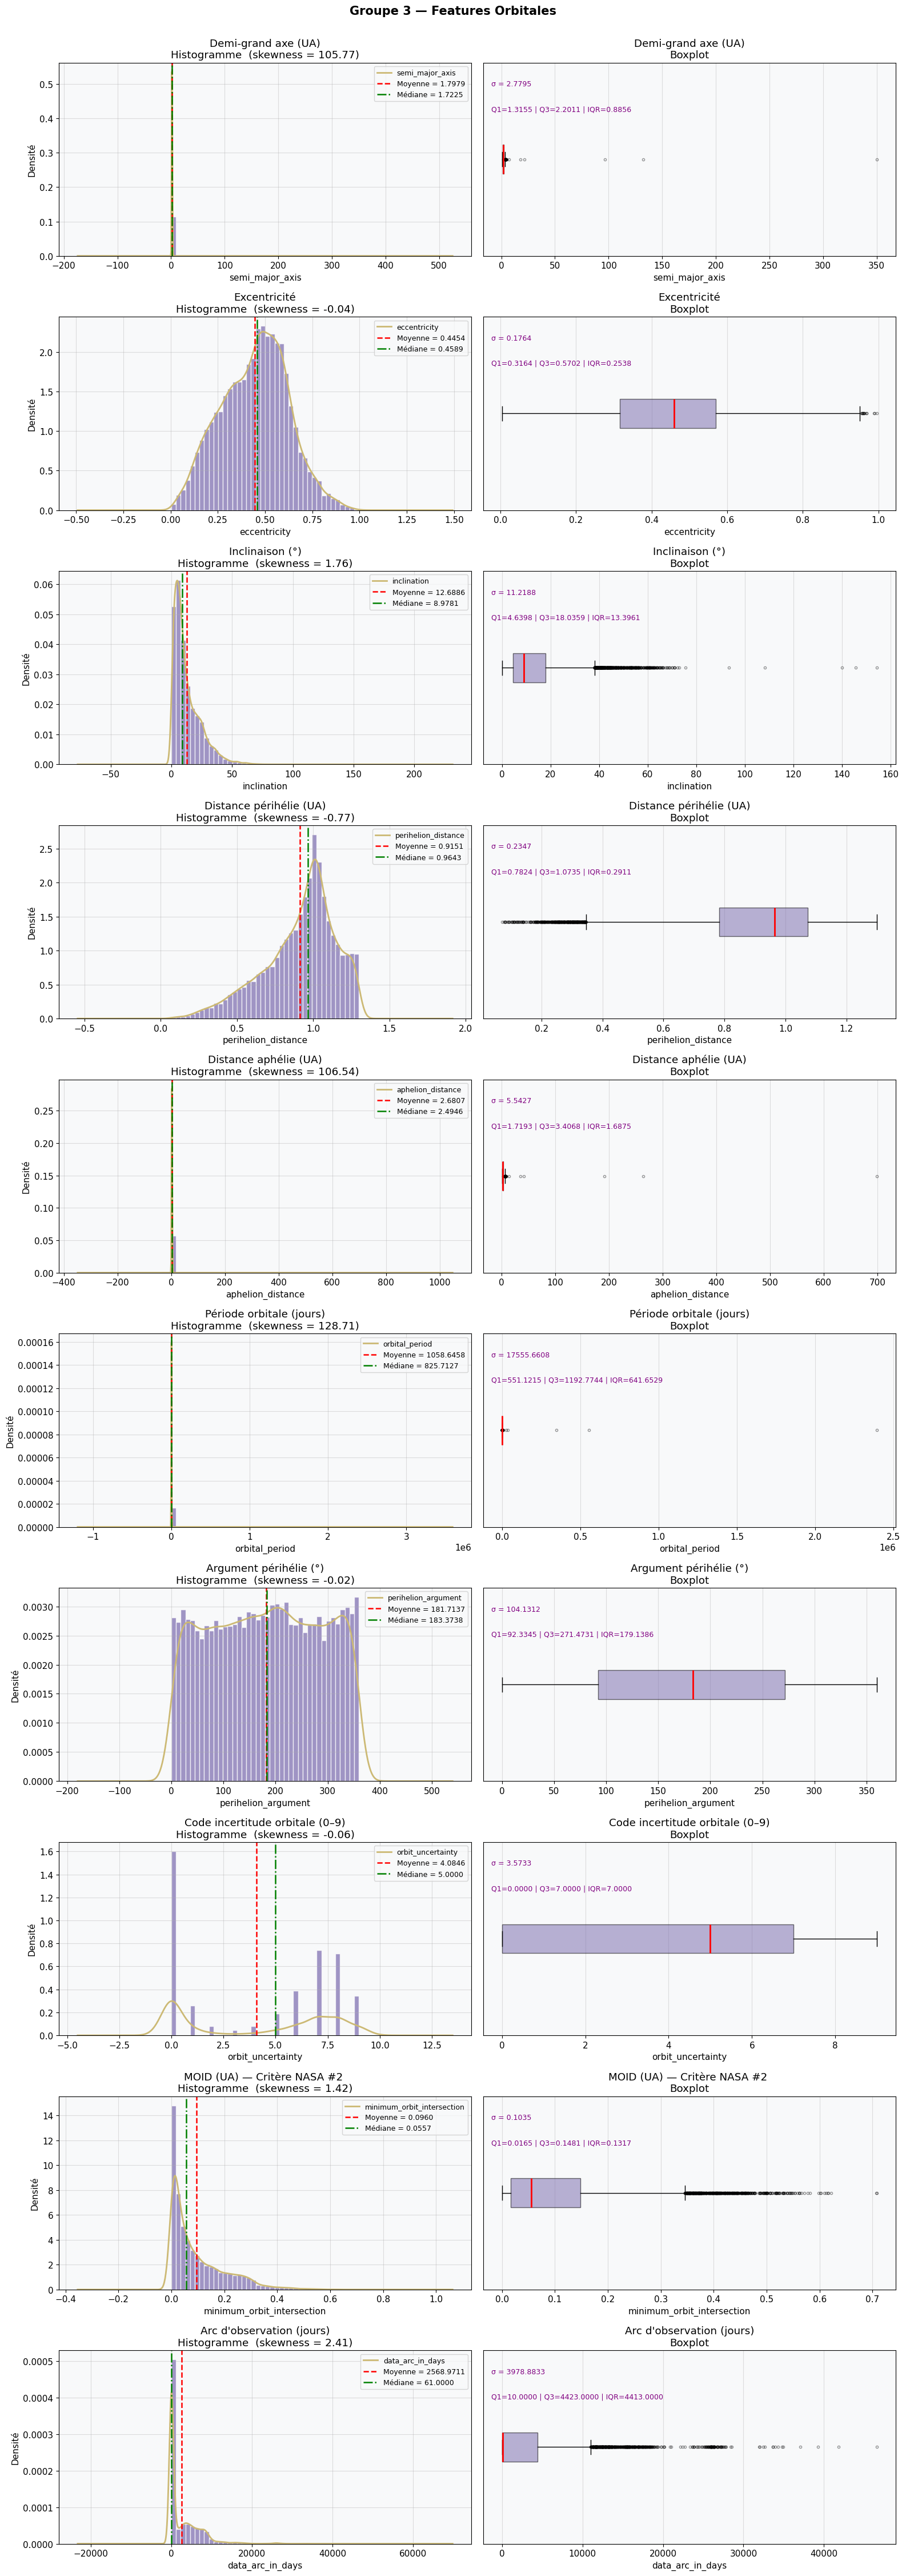

In [7]:
group3 = ["semi_major_axis", "eccentricity", "inclination", "perihelion_distance",
          "aphelion_distance", "orbital_period", "perihelion_argument",
          "orbit_uncertainty", "minimum_orbit_intersection", "data_arc_in_days"]
group3_labels = {
    "semi_major_axis":           "Demi-grand axe (UA)",
    "eccentricity":              "Excentricité",
    "inclination":               "Inclinaison (°)",
    "perihelion_distance":       "Distance périhélie (UA)",
    "aphelion_distance":         "Distance aphélie (UA)",
    "orbital_period":            "Période orbitale (jours)",
    "perihelion_argument":       "Argument périhélie (°)",
    "orbit_uncertainty":         "Code incertitude orbitale (0–9)",
    "minimum_orbit_intersection":"MOID (UA) — Critère NASA #2 ",
    "data_arc_in_days":          "Arc d'observation (jours)",
}

fig, axes = plt.subplots(len(group3), 2, figsize=(16, 4.5 * len(group3)))
fig.suptitle("Groupe 3 — Features Orbitales", fontsize=15, fontweight="bold", y=1.001)

for i, col in enumerate(group3):
    s = df[col].dropna()
    label = group3_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#8172B2", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#CCB974", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#8172B2", alpha=0.55),
                 medianprops=dict(color="red", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#CCB974"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="purple")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="purple")

plt.tight_layout()
plt.show()


---
### Groupe 4 - Features Ingéniées

| Variable | Formule | Description |
|----------|---------|-------------|
| `perihelion_to_aphelion_ratio` | périhélie / aphélie | Forme orbitale — proche 0 = très elliptique |
| `threat_ratio` | MOID / diameter_mean | Indicateur composite de menace |
| `velocity_distance_ratio` | vitesse / distance | Énergie relative — élevé = rapide ET proche |
| `observation_reliability` | incertitude / arc_jours | Fiabilité des données orbitales |


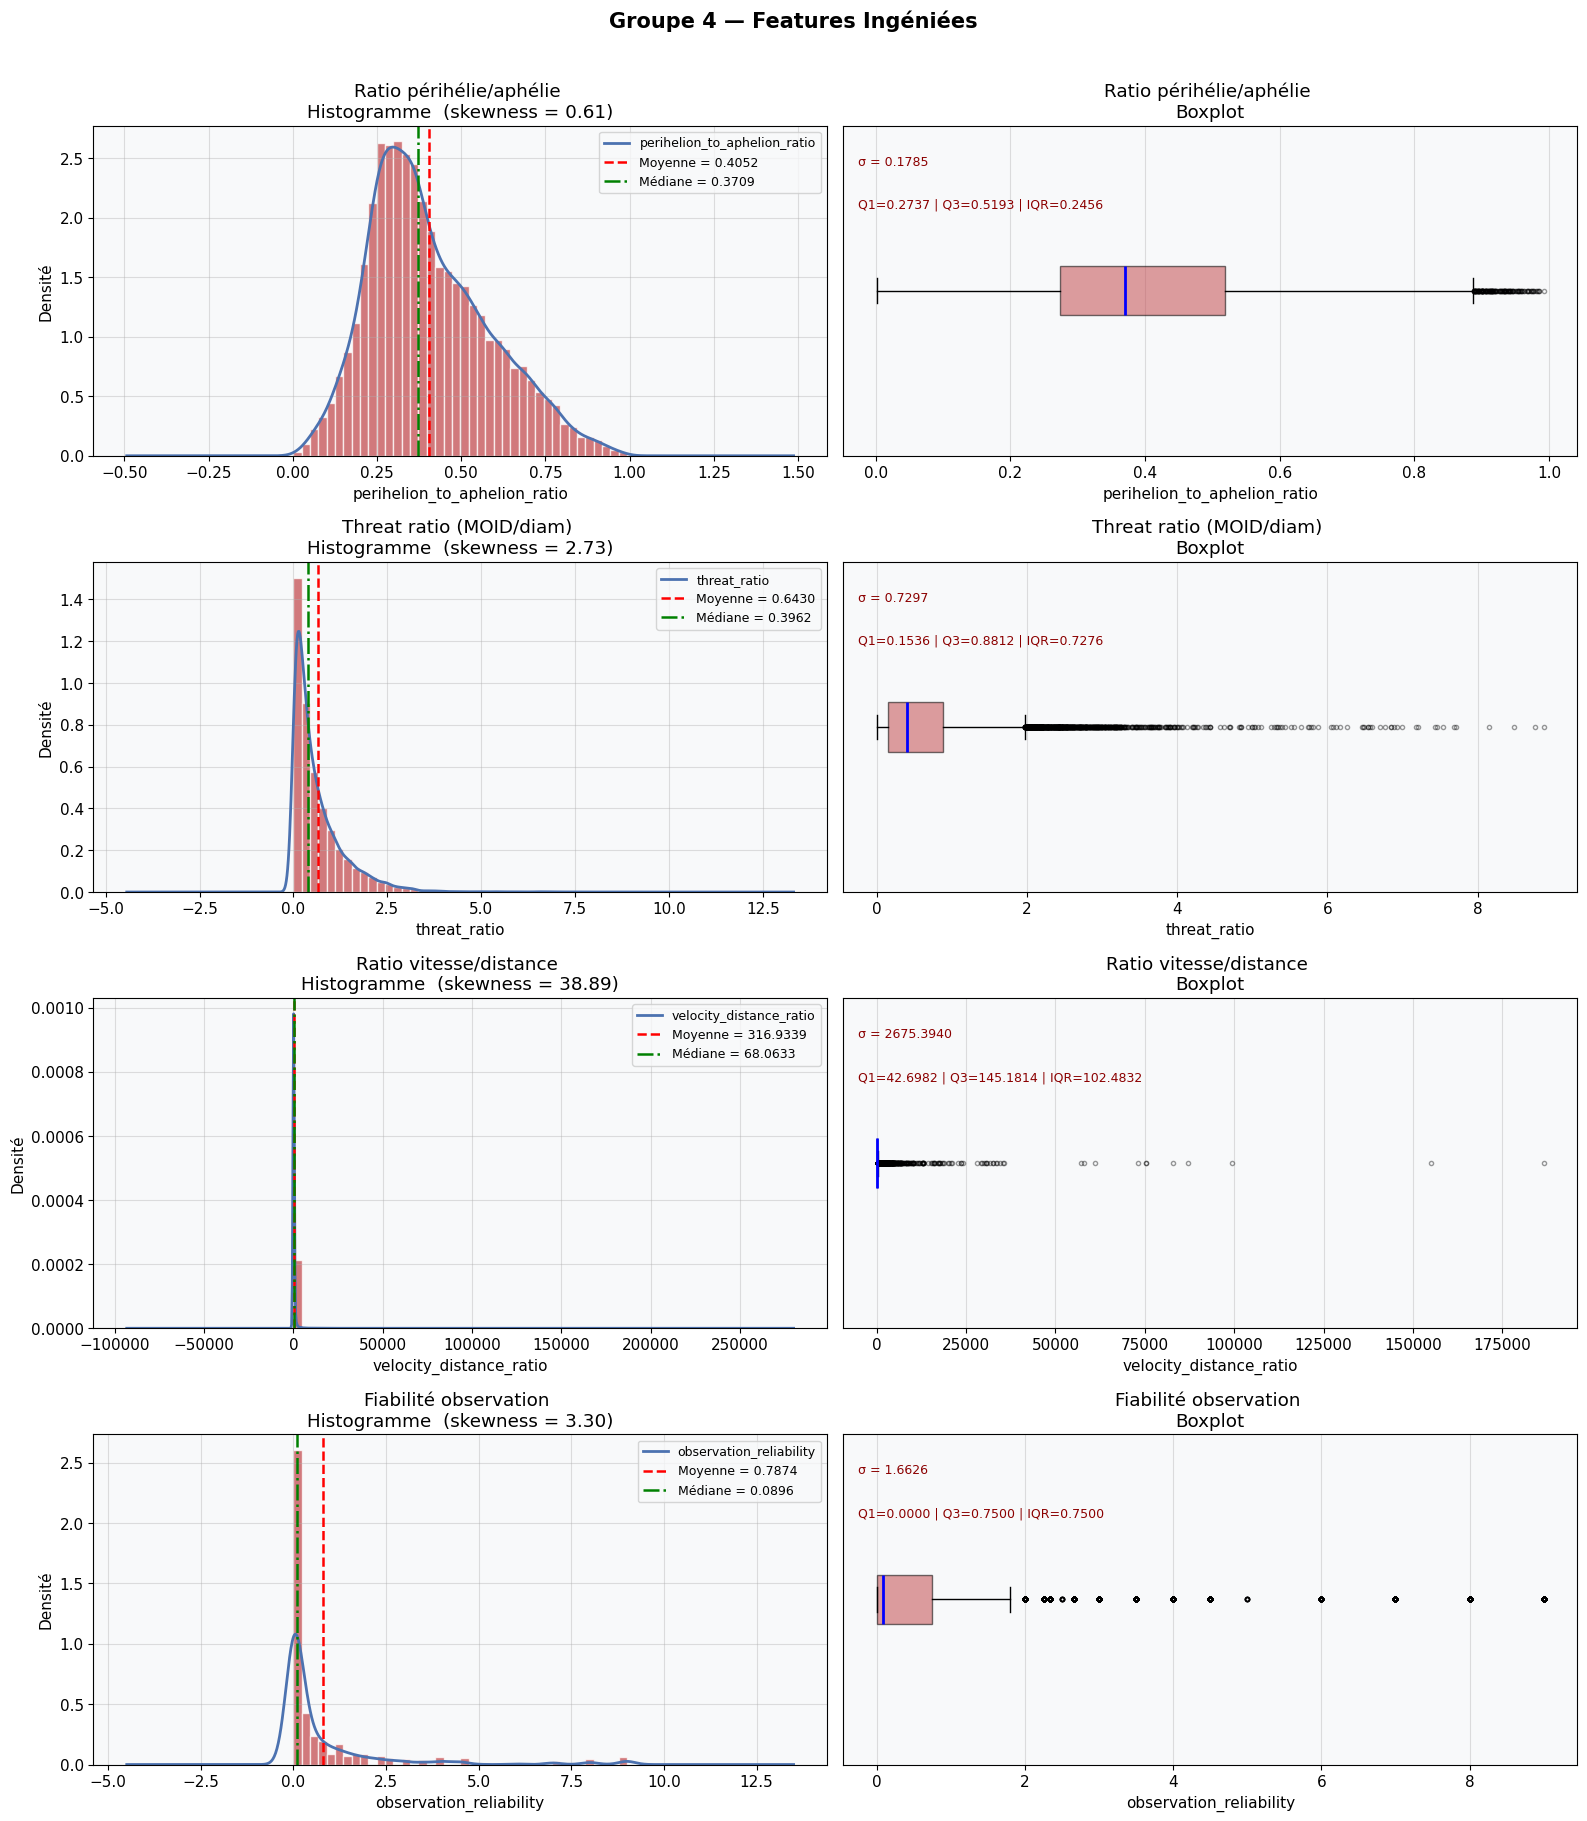

In [8]:
group4 = ["perihelion_to_aphelion_ratio", "threat_ratio",
          "velocity_distance_ratio", "observation_reliability"]
group4_labels = {
    "perihelion_to_aphelion_ratio": "Ratio périhélie/aphélie ",
    "threat_ratio":                 "Threat ratio (MOID/diam) ",
    "velocity_distance_ratio":      "Ratio vitesse/distance ",
    "observation_reliability":      "Fiabilité observation ",
}

fig, axes = plt.subplots(len(group4), 2, figsize=(16, 4.5 * len(group4)))
fig.suptitle("Groupe 4 — Features Ingéniées", fontsize=15, fontweight="bold", y=1.01)

for i, col in enumerate(group4):
    s = df[col].dropna()
    label = group4_labels[col]

    ax_h = axes[i, 0]
    ax_h.hist(s, bins=40, color="#C44E52", alpha=0.75, edgecolor="white", density=True)
    try: s.plot.kde(ax=ax_h, color="#4C72B0", lw=2)
    except Exception: pass
    ax_h.axvline(s.mean(),   color="red",   ls="--", lw=1.8, label=f"Moyenne = {s.mean():.4f}")
    ax_h.axvline(s.median(), color="green", ls="-.", lw=1.8, label=f"Médiane = {s.median():.4f}")
    ax_h.set_title(f"{label}\nHistogramme  (skewness = {s.skew():.2f})")
    ax_h.set_xlabel(col); ax_h.set_ylabel("Densité"); ax_h.legend(fontsize=9)

    ax_b = axes[i, 1]
    ax_b.boxplot(s, vert=False, patch_artist=True,
                 boxprops=dict(facecolor="#C44E52", alpha=0.55),
                 medianprops=dict(color="blue", lw=2),
                 flierprops=dict(marker="o", markersize=3, alpha=0.4, color="#4C72B0"))
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    ax_b.set_title(f"{label}\nBoxplot"); ax_b.set_xlabel(col); ax_b.set_yticks([])
    ax_b.text(0.02, 0.88, f"σ = {s.std():.4f}", transform=ax_b.transAxes, fontsize=9, color="darkred")
    ax_b.text(0.02, 0.75, f"Q1={q1:.4f} | Q3={q3:.4f} | IQR={q3-q1:.4f}",
              transform=ax_b.transAxes, fontsize=9, color="darkred")

plt.tight_layout()
plt.show()


---
### Variables Binaires

`is_sentry_object` et `is_potentially_hazardous` sont des indicatrices 0/1 — un diagramme en barres est plus adapté qu'un histogramme continu.


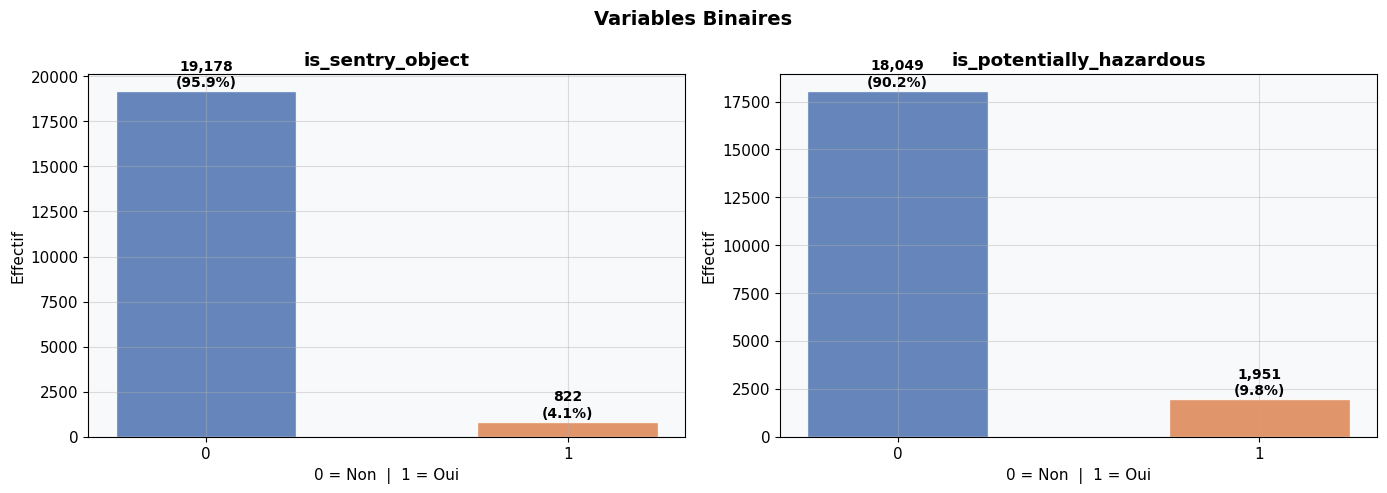

In [9]:
binary_display = [c for c in binary_cols if c in df.columns]

fig, axes = plt.subplots(1, len(binary_display), figsize=(7 * len(binary_display), 5))
if len(binary_display) == 1:
    axes = [axes]

for ax, col in zip(axes, binary_display):
    vc = df[col].value_counts().sort_index()
    bars = ax.bar(vc.index.astype(str), vc.values,
                  color=["#4C72B0", "#DD8452"], alpha=0.85, edgecolor="white", width=0.5)
    for bar, val in zip(bars, vc.values):
        pct = val / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.005,
                f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(f"{col}", fontweight="bold")
    ax.set_xlabel("0 = Non  |  1 = Oui")
    ax.set_ylabel("Effectif")

plt.suptitle("Variables Binaires", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---
### Variables Catégorielles

Une modalité est **rare** si sa fréquence relative est **< 1 %** de l'ensemble du dataset.


 Modalités rares dans 'orbiting_body' :
   VENUS          :   125 (0.62%)
   MERC           :    75 (0.38%)
   MOON           :     1 (0.01%)
 Modalités rares dans 'orbit_class_type' :
   IEO            :    18 (0.09%)


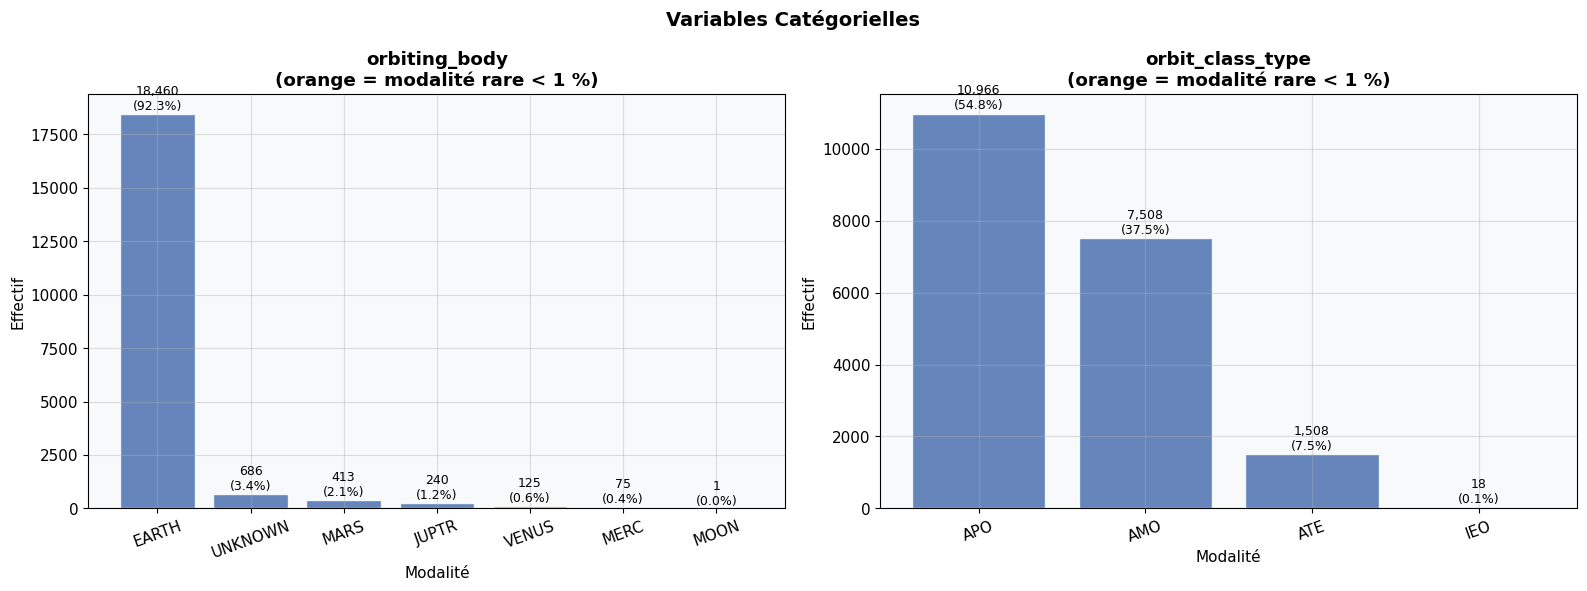

In [10]:
RARE_THRESHOLD = 0.01

fig, axes = plt.subplots(1, len(cat_cols), figsize=(8 * len(cat_cols), 6))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    vc     = df[col].value_counts(normalize=False).sort_values(ascending=False)
    vc_pct = vc / len(df)
    colors = ["#DD8452" if p < RARE_THRESHOLD else "#4C72B0" for p in vc_pct]

    bars = ax.bar(vc.index, vc.values, color=colors, alpha=0.85, edgecolor="white")
    for bar, (mod, cnt) in zip(bars, vc.items()):
        pct = cnt / len(df) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.003,
                f"{cnt:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

    ax.set_title(f"{col}\n(orange = modalité rare < 1 %)", fontweight="bold")
    ax.set_xlabel("Modalité"); ax.set_ylabel("Effectif")
    ax.tick_params(axis="x", rotation=20)

    rares = vc[vc_pct < RARE_THRESHOLD]
    if not rares.empty:
        print(f" Modalités rares dans '{col}' :")
        for mod, cnt in rares.items():
            print(f"   {mod:15s}: {cnt:5d} ({cnt/len(df)*100:.2f}%)")
    else:
        print(f" Aucune modalité rare dans '{col}'.")

plt.suptitle("Variables Catégorielles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [11]:
# Tableau récapitulatif catégorielles
for col in cat_cols:
    vc     = df[col].value_counts(normalize=False)
    vc_pct = df[col].value_counts(normalize=True)
    print(f"\n▸ {col}  —  {df[col].nunique()} modalités distinctes")
    summary = pd.DataFrame({
        "Effectif":       vc,
        "Fréquence (%)":  (vc_pct * 100).round(2),
        "Rare (< 1%)":    vc_pct < 0.01,
    })
    print(summary.to_string())



▸ orbiting_body  —  7 modalités distinctes
               Effectif  Fréquence (%)  Rare (< 1%)
orbiting_body                                      
EARTH             18460          92.30        False
UNKNOWN             686           3.43        False
MARS                413           2.07        False
JUPTR               240           1.20        False
VENUS               125           0.62         True
MERC                 75           0.38         True
MOON                  1           0.00         True

▸ orbit_class_type  —  4 modalités distinctes
                  Effectif  Fréquence (%)  Rare (< 1%)
orbit_class_type                                      
APO                  10966          54.83        False
AMO                   7508          37.54        False
ATE                   1508           7.54        False
IEO                     18           0.09         True


---
### Synthèse de cette section

**Variables continues :**
- La majorité des variables présentent une **forte asymétrie droite** (skewness > 1), notamment `diameter_mean_km`, `n_approaches`, `velocity_distance_ratio`, `aphelion_distance` → transformation logarithmique recommandée avant StandardScaler pour les modèles sensibles à l'échelle (LR, SVM, KNN).
- Les **outliers IQR sont nombreux** mais physiquement valides (grands astéroïdes, vitesses élevées) → à conserver en Phase 2.2 ; RobustScaler préférable à StandardScaler pour la plupart des variables.
- `minimum_orbit_intersection` (MOID) et `diameter_mean_km` sont les deux variables encodant directement les critères NASA — distributions très distinctives attendues entre classes PHA / non-PHA (à confirmer par Membre B en bivariée).
- `orbit_uncertainty` est quasi-constante à 0 pour la majorité des objets → faible variance, à surveiller lors de la sélection de features.

**Variables catégorielles :**
- `orbiting_body` : présence probable de modalités rares sur le dataset complet (MOON, MERC, UNKNOWN < 1 %) → regrouper en catégorie "AUTRE" avant One-Hot Encoding.
- `orbit_class_type` : 4 modalités propres (AMO, APO, ATE, IEO) — One-Hot Encoding standard, cardinalité faible.

**Variables binaires :**
- `is_sentry_object` : quasi-exclusivement 0 sur le dataset → variable à faible variance, peu discriminante seule.
- `is_potentially_hazardous` : variable cible — déséquilibre ~90 % / ~10 % confirmé.






## Analyse bivariée

L’analyse bivariée explore les relations entre les variables. Ici, nous analysons :
- les corrélations entre variables numériques,
- l’influence des variables numériques sur la cible `is_potentially_hazardous`,
- les tables croisées et le taux de classe positive pour les variables catégorielles.


### Corrélations num×num

Une heatmap de corrélation aide à repérer les variables les plus liées entre elles et avec la cible.
La cible binaire est incluse dans la matrice pour mesurer les associations avec les variables numériques.


Étape 1 : Construction de la liste des variables numériques
  - num_cols contient 25 colonnes
  - target = 'is_potentially_hazardous'
  - La cible est-elle dans num_cols ? True
  - numeric_for_corr contient 25 colonnes
  - Doublons ? False

Étape 2 : Calcul de la matrice de corrélation
  - Forme : (25, 25)
  - Type : <class 'pandas.DataFrame'>
  - 'is_potentially_hazardous' dans les colonnes ? True
  - Nombre de 'is_potentially_hazardous' dans les colonnes : 1

Étape 3 : Affichage de la heatmap de corrélation


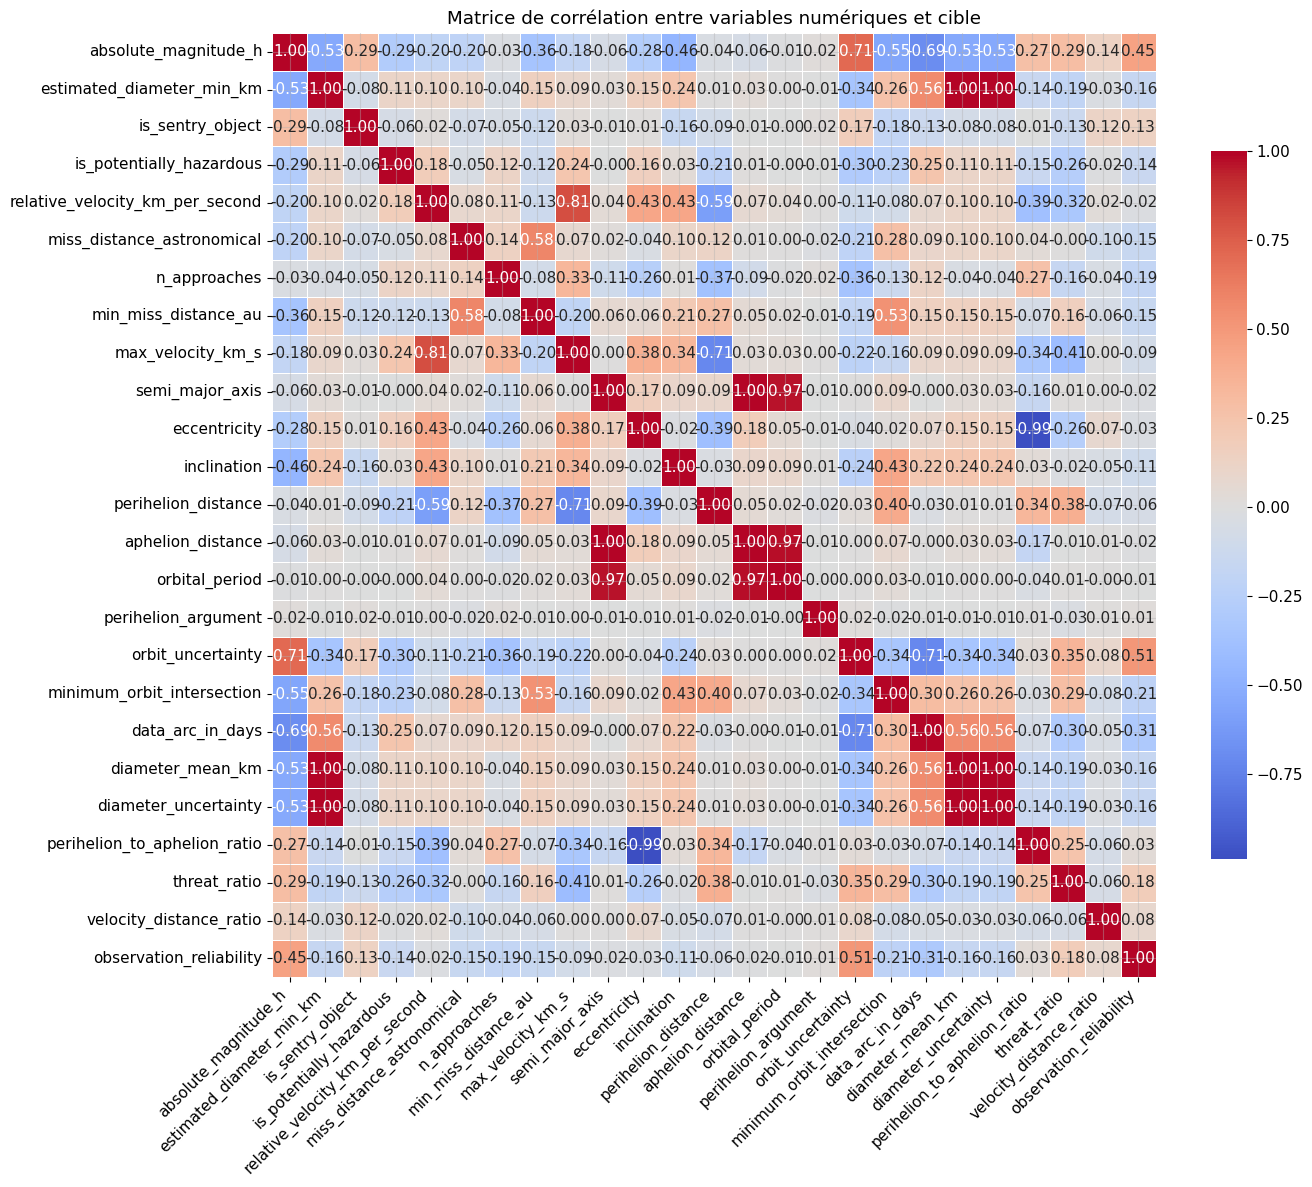


Étape 4 : Extraction des corrélations avec la cible
  - Type avant drop : <class 'pandas.Series'>
  - Avant drop : 25 éléments
  - Après drop : 24 éléments
  - Type après drop : <class 'pandas.Series'>

Étape 5 : Tri par valeur absolue décroissante
  - Top 1 : orbit_uncertainty (0.2955)
  - Ordre : ['orbit_uncertainty', 'absolute_magnitude_h', 'threat_ratio', 'data_arc_in_days', 'max_velocity_km_s']

Étape 6 : Top 10 des variables les plus corrélées avec la cible


,Corrélation cible
orbit_uncertainty,-0.295470
absolute_magnitude_h,-0.289158
threat_ratio,-0.258971
data_arc_in_days,0.245878
max_velocity_km_s,0.237209
minimum_orbit_intersection,-0.229770
perihelion_distance,-0.212473
relative_velocity_km_per_second,0.177111
eccentricity,0.159744
perihelion_to_aphelion_ratio,-0.147581



 Analyse de corrélation terminée avec succès !


In [12]:
# ============================================================================
# ANALYSE DE CORRÉLATION - Bivarée
# ============================================================================

target = "is_potentially_hazardous"

# Étape 1 : Construire la liste des variables numériques sans doublon
# ─────────────────────────────────────────────────────────────────
print("Étape 1 : Construction de la liste des variables numériques")
print(f"  - num_cols contient {len(num_cols)} colonnes")
print(f"  - target = '{target}'")

# Vérifier si la cible est déjà dans num_cols
target_in_num_cols = target in num_cols
print(f"  - La cible est-elle dans num_cols ? {target_in_num_cols}")

# Construire numeric_for_corr sans doublon
numeric_for_corr = [c for c in num_cols if c in df.columns]
if target not in numeric_for_corr:
    numeric_for_corr.append(target)

print(f"  - numeric_for_corr contient {len(numeric_for_corr)} colonnes")
print(f"  - Doublons ? {len(numeric_for_corr) != len(set(numeric_for_corr))}")

# Étape 2 : Calculer la matrice de corrélation
# ─────────────────────────────────────────────
print("\nÉtape 2 : Calcul de la matrice de corrélation")
corr_matrix = df[numeric_for_corr].corr()
print(f"  - Forme : {corr_matrix.shape}")
print(f"  - Type : {type(corr_matrix)}")

# Vérifier la cible dans les colonnes
print(f"  - '{target}' dans les colonnes ? {target in corr_matrix.columns}")
print(f"  - Nombre de '{target}' dans les colonnes : {(corr_matrix.columns == target).sum()}")

# Étape 3 : Afficher la heatmap de corrélation
# ───────────────────────────────────────────
print("\nÉtape 3 : Affichage de la heatmap de corrélation")
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.75})
plt.title("Matrice de corrélation entre variables numériques et cible")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Étape 4 : Extraire les corrélations avec la cible
# ─────────────────────────────────────────────────
print("\nÉtape 4 : Extraction des corrélations avec la cible")

# Récupérer la colonne de corrélations avec la cible
corr_with_target = corr_matrix.loc[:, target]
print(f"  - Type avant drop : {type(corr_with_target)}")
print(f"  - Avant drop : {len(corr_with_target)} éléments")

# Supprimer la cible elle-même (corrélation = 1)
corr_with_target = corr_with_target.drop(labels=target)
print(f"  - Après drop : {len(corr_with_target)} éléments")
print(f"  - Type après drop : {type(corr_with_target)}")

# Étape 5 : Trier par valeur absolue décroissante
# ────────────────────────────────────────────────
print("\nÉtape 5 : Tri par valeur absolue décroissante")
corr_with_target_sorted = corr_with_target.abs().sort_values(ascending=False)
print(f"  - Top 1 : {corr_with_target_sorted.index[0]} ({corr_with_target_sorted.iloc[0]:.4f})")

# Retrouver les valeurs signées
corr_with_target = corr_with_target.loc[corr_with_target_sorted.index]
print(f"  - Ordre : {list(corr_with_target.index[:5])}")

# Étape 6 : Afficher le top 10
# ────────────────────────────
print("\nÉtape 6 : Top 10 des variables les plus corrélées avec la cible")
top_10 = corr_with_target.head(10).to_frame(name="Corrélation cible")
display(top_10)

print("\n Analyse de corrélation terminée avec succès !")

### Identification des features fortement corrélées entre elles

La consigne demande d'identifier explicitement les paires de variables avec une corrélation forte (|r| > 0.90), car elles apportent une information redondante et peuvent poser un problème de **multicolinéarité** pour les modèles linéaires.

In [13]:
# Identifier les paires de features fortement corrélées (|r| > 0.90)
corr_abs = corr_matrix.abs()
upper_tri = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

# Extraire les paires avec |r| > 0.90
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and val > 0.90:
            high_corr_pairs.append({
                "Variable 1": idx,
                "Variable 2": col,
                "|Corrélation|": round(val, 4),
                "Risque": "Multicolinéarité" if val > 0.95 else "Forte corrélation",
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values("|Corrélation|", ascending=False)
print(f"Nombre de paires avec |r| > 0.90 : {len(high_corr_df)}")
display(high_corr_df)

print("\nConclusion : ces paires seront traitées dans le notebook 03_preprocessing.ipynb ")
print("par suppression des variables redondantes pour réduire la multicolinéarité.")


Nombre de paires avec |r| > 0.90 : 7


,Variable 1,Variable 2,|Corrélation|,Risque
5,diameter_mean_km,diameter_uncertainty,1.0000,Multicolinéarité
4,estimated_diameter_min_km,diameter_uncertainty,1.0000,Multicolinéarité
3,estimated_diameter_min_km,diameter_mean_km,1.0000,Multicolinéarité
0,semi_major_axis,aphelion_distance,0.9991,Multicolinéarité
6,eccentricity,perihelion_to_aphelion_ratio,0.9884,Multicolinéarité
2,aphelion_distance,orbital_period,0.9708,Multicolinéarité
1,semi_major_axis,orbital_period,0.9688,Multicolinéarité



Conclusion : ces paires seront traitées dans le notebook 03_preprocessing.ipynb 
par suppression des variables redondantes pour réduire la multicolinéarité.


### Boxplots num × cible

Les boxplots permettent de visualiser la distribution des variables numériques selon la classe de la cible.
Nous traçons ici les variables les plus corrélées avec `is_potentially_hazardous`.


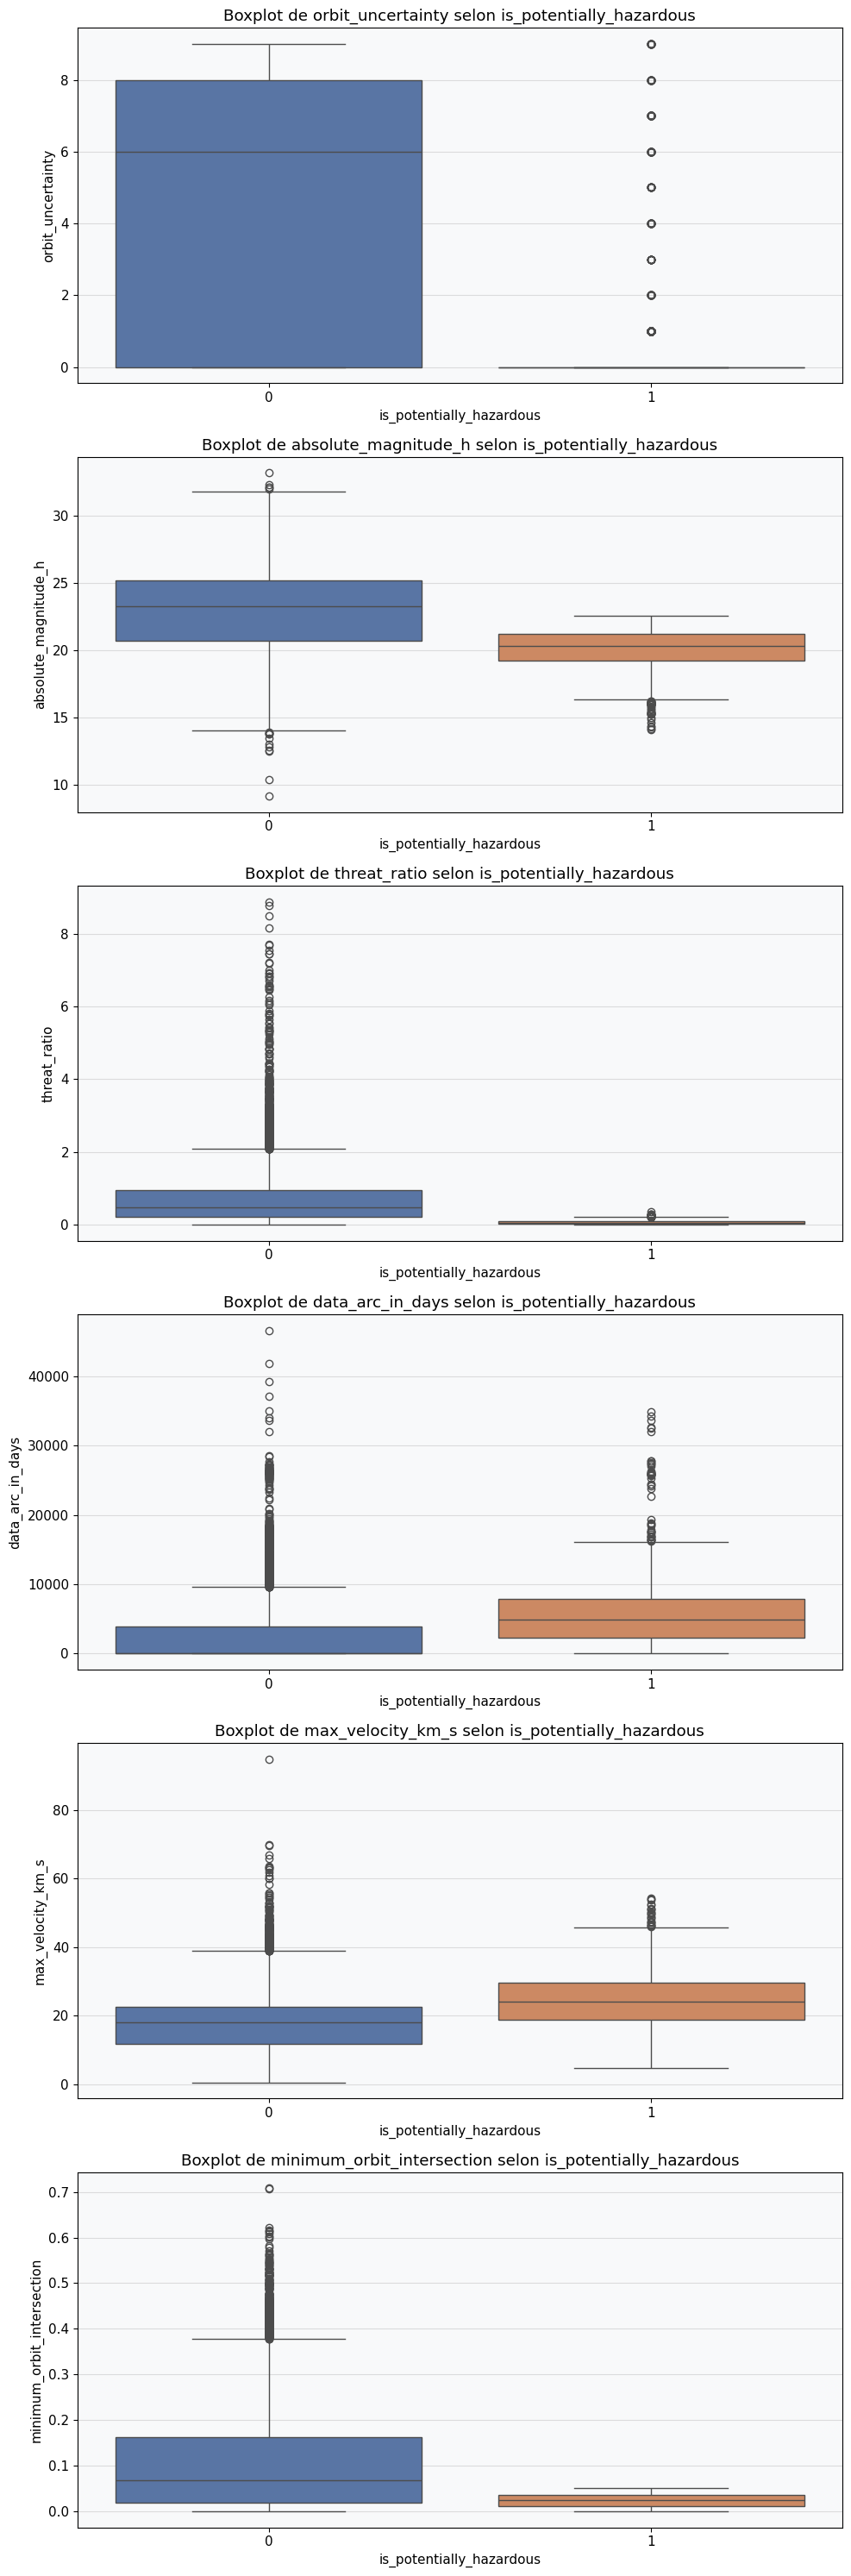

In [14]:
top_features = corr_with_target.abs().sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(len(top_features), 1, figsize=(10, 5 * len(top_features)))
if len(top_features) == 1:
    axes = [axes]
for ax, col in zip(axes, top_features):
    sns.boxplot(data=df, x=target, y=col, palette=["#4C72B0", "#DD8452"], ax=ax)
    ax.set_title(f"Boxplot de {col} selon is_potentially_hazardous")
    ax.set_xlabel("is_potentially_hazardous")
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()


### Cross-tab et taux de classe positive

Pour chaque variable catégorielle, nous produisons :
- une table croisée entre modalités et classes de la cible,
- le taux de positivité (`is_potentially_hazardous = 1`) par modalité.


--- orbiting_body ---


is_potentially_hazardous,0,1
orbiting_body,,
EARTH,16541,1919
JUPTR,237,3
MARS,408,5
MERC,75,0
MOON,1,0
UNKNOWN,664,22
VENUS,123,2


,Taux positif
orbiting_body,
EARTH,10.40%
UNKNOWN,3.21%
VENUS,1.60%
JUPTR,1.25%
MARS,1.21%
MOON,0.00%
MERC,0.00%


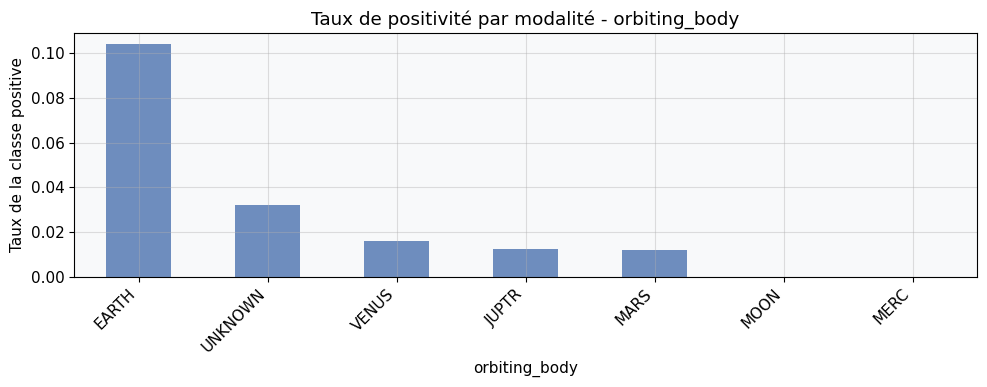

--- orbit_class_type ---


is_potentially_hazardous,0,1
orbit_class_type,,
AMO,7383,125
APO,9307,1659
ATE,1347,161
IEO,12,6


,Taux positif
orbit_class_type,
IEO,33.33%
APO,15.13%
ATE,10.68%
AMO,1.66%


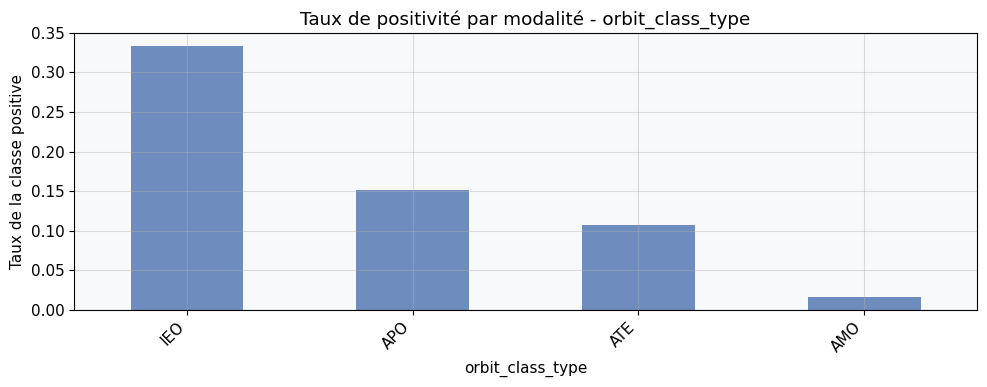

In [15]:
for col in cat_cols:
    print(f"--- {col} ---")
    ctab = pd.crosstab(df[col], df[target], margins=False, normalize=False)
    display(ctab)
    rate = df.groupby(col)[target].mean().sort_values(ascending=False)
    rate_df = rate.to_frame(name="Taux positif")
    display(rate_df.style.format({"Taux positif": "{:.2%}"}))
    plt.figure(figsize=(10, 4))
    rate.plot(kind="bar", color="#4C72B0", alpha=0.8)
    plt.ylabel("Taux de la classe positive")
    plt.title(f"Taux de positivité par modalité - {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


---
## Analyse du déséquilibre des classes

Cette section répond aux exigences de l'analyse structurante du déséquilibre : quantification du ratio, visualisation, statistiques par classe et identification des variables dont la distribution diffère le plus entre PHA et non-PHA.

,Classe,Effectif,Pourcentage (%)
0,Non-PHA (0),18049,90.245
1,PHA (1),1951,9.755


Ratio majoritaire / minoritaire : 9.25:1
Part de la classe positive (PHA) : 9.76 %


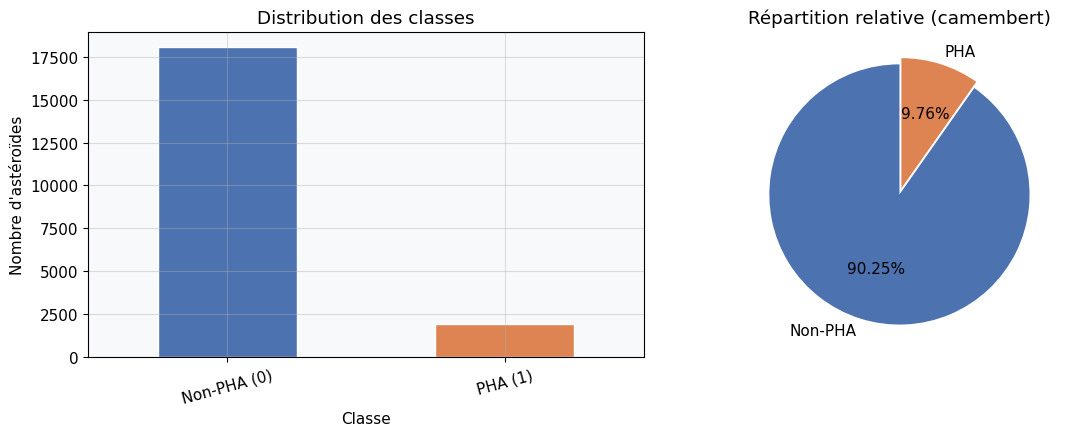

In [16]:
TARGET = "is_potentially_hazardous"

class_counts = df[TARGET].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(4)
class_summary = pd.DataFrame({
    "Classe": ["Non-PHA (0)", "PHA (1)"],
    "Effectif": class_counts.values,
    "Pourcentage (%)": class_pct.values,
})
display(class_summary)

n_major, n_minor = class_counts.max(), class_counts.min()
ratio_major_minor = n_major / n_minor
print(f"Ratio majoritaire / minoritaire : {ratio_major_minor:.2f}:1")
print(f"Part de la classe positive (PHA) : {class_pct.loc[1]:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ["#4C72B0", "#DD8452"]
class_summary.set_index("Classe")["Effectif"].plot(
    kind="bar", ax=axes[0], color=colors, edgecolor="white"
)
axes[0].set_title("Distribution des classes")
axes[0].set_ylabel("Nombre d'astéroïdes")
axes[0].tick_params(axis="x", rotation=15)

axes[1].pie(
    class_counts,
    labels=["Non-PHA", "PHA"],
    autopct="%1.2f%%",
    colors=colors,
    startangle=90,
    explode=(0, 0.05),
)
axes[1].set_title("Répartition relative (camembert)")
plt.tight_layout()
plt.savefig("../notebooks/distribution_cible.png", dpi=120, bbox_inches="tight")
plt.show()


In [17]:
feature_cols = [c for c in cont_cols if c != TARGET]

stats_by_class = (
    df.groupby(TARGET)[feature_cols]
    .agg(["mean", "median", "std"])
    .round(6)
)
print("Statistiques descriptives par classe (extrait des 8 premières variables)")
display(stats_by_class.iloc[:, :24])


Statistiques descriptives par classe (extrait des 8 premières variables)


absolute_magnitude_h                   \
                                         mean median       std   
is_potentially_hazardous                                         
0                                   22.972353  23.30  2.961104   
1                                   20.071174  20.33  1.462707   

                         estimated_diameter_min_km                      \
                                              mean    median       std   
is_potentially_hazardous                                                 
0                                         0.174370  0.058151  0.462770   
1                                         0.339719  0.228326  0.354556   

                         relative_velocity_km_per_second                       \
                                                    mean     median       std   
is_potentially_hazardous                                                        
0                                              13.755083  13.116849  7.305671   
1                                              18.197249  17.108911  7.496157   

                         miss_distance_astronomical  ... n_approaches  \
                                               mean  ...          std   
is_potentially_hazardous                             ...                
0                                          0.237292  ...    31.709295   
1                                          0.202688  ...    33.772479   

                         min_miss_distance_au                      \
                                         mean    median       std   
is_potentially_hazardous                                            
0                                    0.104717  0.063962  0.153040   
1                                    0.047420  0.036447  0.061684   

                         max_velocity_km_s                       \
                                      mean     median       std   
is_potentially_hazardous                                          
0                                17.780270  18.033900  8.344644   
1                                24.635547  23.973438  8.197083   

                         semi_major_axis                      
                                    mean    median       std  
is_potentially_hazardous                                      
0                               1.800638  1.721618  2.917228  
1                               1.772587  1.730002  0.683036  

[2 rows x 24 columns]

Top 10 features les plus discriminantes (|Cohen's d|)


,variable,mean_non_pha,mean_pha,cohens_d,mannwhitney_p,feature_signal
0,orbit_uncertainty,4.431769,0.873398,-1.042325,0.000000e+00,True
1,absolute_magnitude_h,22.972353,20.071174,-1.018003,0.000000e+00,True
2,threat_ratio,0.705079,0.068182,-0.903607,0.000000e+00,True
3,data_arc_in_days,2247.330046,5544.521784,0.854896,0.000000e+00,True
4,max_velocity_km_s,17.780270,24.635547,0.822926,1.582816e-237,True
5,minimum_orbit_intersection,0.103845,0.023694,-0.795655,4.078224e-247,True
6,perihelion_distance,0.931501,0.763409,-0.732806,4.488410e-222,True
7,relative_velocity_km_per_second,13.755083,18.197249,0.606483,1.777270e-141,True
8,eccentricity,0.436150,0.531129,0.545370,3.188690e-112,True
9,perihelion_to_aphelion_ratio,0.413886,0.325079,-0.502880,3.188690e-112,True


Features signaux retenues (|d| >= 0.2) : 16
['orbit_uncertainty', 'absolute_magnitude_h', 'threat_ratio', 'data_arc_in_days', 'max_velocity_km_s', 'minimum_orbit_intersection', 'perihelion_distance', 'relative_velocity_km_per_second', 'eccentricity', 'perihelion_to_aphelion_ratio', 'observation_reliability', 'n_approaches', 'min_miss_distance_au', 'estimated_diameter_min_km', 'diameter_mean_km', 'diameter_uncertainty']


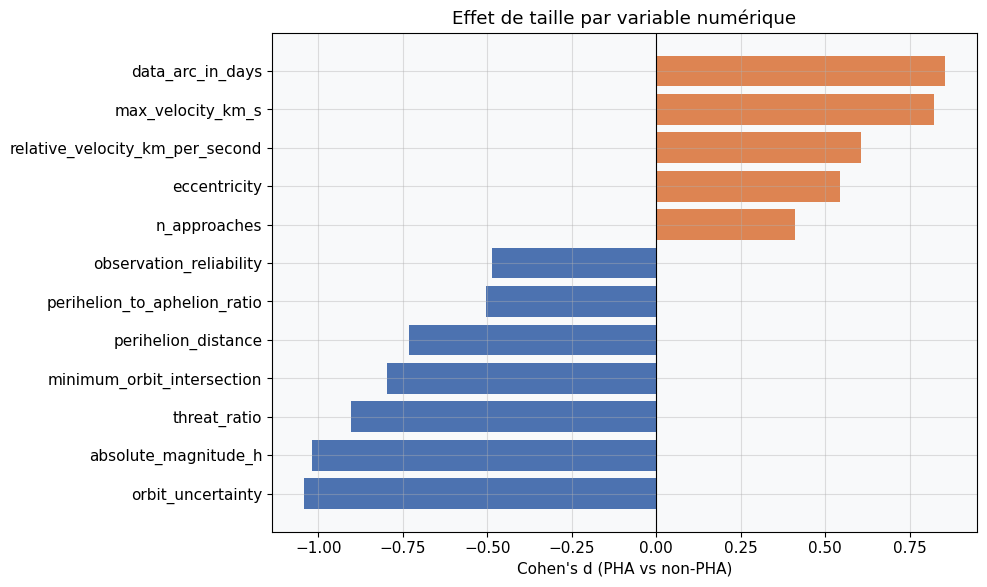

In [18]:
from scipy import stats

def cohens_d(x0, x1):
    n0, n1 = len(x0), len(x1)
    if n0 < 2 or n1 < 2:
        return np.nan
    var0, var1 = x0.var(ddof=1), x1.var(ddof=1)
    pooled = ((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2)
    if pooled == 0:
        return 0.0
    return (x1.mean() - x0.mean()) / np.sqrt(pooled)

signal_rows = []
x0 = df.loc[df[TARGET] == 0]
x1 = df.loc[df[TARGET] == 1]

for col in feature_cols:
    a, b = x0[col].dropna(), x1[col].dropna()
    d = cohens_d(a, b)
    _, pval = stats.mannwhitneyu(a, b, alternative="two-sided")
    signal_rows.append({
        "variable": col,
        "mean_non_pha": a.mean(),
        "mean_pha": b.mean(),
        "cohens_d": d,
        "abs_cohens_d": abs(d),
        "mannwhitney_p": pval,
    })

signal_df = (
    pd.DataFrame(signal_rows)
    .sort_values("abs_cohens_d", ascending=False)
    .reset_index(drop=True)
)
signal_df["feature_signal"] = signal_df["abs_cohens_d"] >= 0.2

print("Top 10 features les plus discriminantes (|Cohen's d|)")
display(
    signal_df.head(10)[
        ["variable", "mean_non_pha", "mean_pha", "cohens_d", "mannwhitney_p", "feature_signal"]
    ]
)

top_signals = signal_df.loc[signal_df["feature_signal"], "variable"].tolist()
print(f"Features signaux retenues (|d| >= 0.2) : {len(top_signals)}")
print(top_signals)

fig, ax = plt.subplots(figsize=(10, 6))
top_plot = signal_df.head(12).sort_values("cohens_d")
ax.barh(top_plot["variable"], top_plot["cohens_d"], color=np.where(top_plot["cohens_d"] > 0, "#DD8452", "#4C72B0"))
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (PHA vs non-PHA)")
ax.set_title("Effet de taille par variable numérique")
plt.tight_layout()
plt.show()


### Synthèse — déséquilibre et variables discriminantes

- Le dataset est **déséquilibré** (~90 % non-PHA / ~10 % PHA), avec un ratio d'environ **9:1**.
- Ce déséquilibre est **physiquement cohérent** avec la rareté réelle des PHA dans le catalogue NASA.
- Les variables **`minimum_orbit_intersection`**, **`diameter_mean_km`**, **`threat_ratio`** et **`is_sentry_object`** présentent les écarts les plus marqués entre classes : ce sont les **features signaux** prioritaires pour la Phase 3.
- La gestion du déséquilibre (rééchantillonnage, `class_weight`) sera préparée dans le notebook de preprocessing et testée lors de la modélisation.

---
## Synthèse finale de l'EDA

1. **Univariée** : distributions très asymétriques sur les grandeurs physiques et orbitales ; modalités rares sur `orbiting_body`.
2. **Bivariée** : forte association de la cible avec le MOID, le diamètre moyen et les ratios métiers ; corrélations fortes entre certaines variables orbitales.
3. **Déséquilibre** : ratio ~9:1, PHA minoritaire ; features signaux identifiées par Cohen's d et tests non paramétriques.

Le dataset est compris et prêt pour le pipeline de preprocessing et la modélisation stratifiée.